# Purpose of the Code

The goal of this notebook is to extract EMG signals recorded using Myo armband and Trigno Avanti sensors, process the raw data, extract meaningful features, and store the resulting information in a structured DataFrame format.

## Environment Setup

In [1]:
# pip install libemg  # Required only if you have never installed the libemg package
# pip install --upgrade paramiko cryptography  # Needed during first-time installation of libemg to resolve dependencies

In [2]:
import os
import pandas as pd
import numpy as np
import sys
sys.path.append('../lib')
from import_emg_file import import_data_from_myo, import_data_from_trigno
from myo_utils import myo_dataframe_edit, myo_extract_muscle_emg
from trigno_utils import trigno_dataframe_edit, trigno_extract_muscle_emg
from emg_utils import plot_emg_signal, emg_filters, extract_emg_windows_v2, extract_emg_features, normalize_emg_data, align_and_get_bkps_trigno
from features_utils import combine_multiple_features_lists, detect_segments_v2, assign_emg_labels_v2, compute_offset_trigno_myo

In [3]:
# Parameters
subj = "03"
date = "_test"
folder = "Seq1"
intensity_map = {"Seq1": ["medium", "light", "heavy"],
                "Seq2": ["medium", "heavy", "light"],
                "Seq3": ["heavy", "medium", "light"]}
intensity_level = intensity_map.get(folder, [])
channel_numbers = [1, 2, 3, 4, 5, 6, 7, 8]  # Possible channels: from 1 to 8
channel_ref_number = 5 
channel_names = [f"channel_{num}" for num in channel_numbers] # Create channel of interest names
channel_ref = f"channel_{channel_ref_number}" # Reference channel for true label assignment
muscle_names = ["biceps", "triceps"]  # Target muscle: "biceps", "triceps", "forearm1", or "forearm2"
muscle_ref = "biceps" # Reference muscle for true label assignment
lenght = 28 # n° of "interesting" columns of Trigno CSV file

w_d = 0.2  # Window duration in seconds for feature extraction
ov = 0.5  # Overlap percentage between windows (e.g., 0.5 = 50%)
step = w_d * ov
n_lifts = 5  # Number of lifts
fs_myo = 200 # Frequency of Myo armband
smooth_threshold_trigno = 0.005
smooth_threshold_myo = 3
time_factor = 2
duration = 70
rest = 60 
n_segments = 3

windows_s = [(i * (duration + rest), i * (duration + rest) + duration) for i in range(n_segments)]
windows_trigno = [(i * (duration + rest) + 5, i * (duration + rest) + duration + 5) for i in range(n_segments)]
windows_per_segment = int(np.ceil((duration - w_d) / step)) 
windows_idx_list_myo = [] 
fs_list_myo = []  # Initialize list to store sampling frequencies
windows_idx_list_trigno = [] 
fs_list_trigno = []  # Initialize list to store sampling frequencies
diff = [] # Offsets between trigno and myo signals
breakpoints_trigno = []
emg_norm_cut_myo = {}
emg_norm_cut_trigno = {}

# Feature lists
features_list_norm = ['MAV', 'WL', 'VAR', 'LD', 'SAMPEN', 'MPK', 'WAMP']  # Features on normalized signal
features_list_filt = ['ZC', 'SSC', 'KURT', 'SKEW']  # Features on filtered signal
features_list_freq = ['MNF', 'MNP', 'SM', 'ISD']  # Frequency-domain features

# Paths for input and output
input_folder_myo = f'../data/acquisitions/myo/{date}/S{subj}/{folder}/'  # Input folder with raw data
input_folder_trigno = f'../data/acquisitions/trigno/{date}/S{subj}/{folder}/'  # Input folder with raw data
output_folder = f'../data/extracted_features/{date}/'  # Output folder to save extracted features
output_filename = f"S{subj}_{folder}_features.csv"  # Name of the output CSV file
mvc_myo = f'../data/mvc_values/myo/{date}/S{subj}.csv' # Name of the mvc dataset
mvc_trigno = f'../data/mvc_values/trigno/{date}/S{subj}.csv' # Name of the mvc dataset

folder_path_new_mvc = f'../data/mvc_values/{date}'
file_name_new_mvc = f'S{subj}_{folder}.csv'
full_path_new_mvc = os.path.join(folder_path_new_mvc, file_name_new_mvc)

# Loading Data Files

In [4]:
dataframes_myo = import_data_from_myo(input_folder_myo)  # Import raw data from Myo folder
dataframes_myo = [myo_dataframe_edit(df) for df in dataframes_myo]  # Format each imported dataframe

In [5]:
dataframes_trigno = import_data_from_trigno(input_folder_trigno, lenght)  # Import raw data from Trigno folder
dataframes_trigno = [trigno_dataframe_edit(df) for df in dataframes_trigno]  # Format each imported dataframe

In [6]:
muscle_emg_raw_myo, emg_time_myo = myo_extract_muscle_emg(dataframes_myo, channel_names, fs_myo)  # Extract EMG signals for the specified channels

In [7]:
#for i in range(len(emg_time_myo)):
#    emg_signal = muscle_emg_raw_myo[channel_ref][i]
#    time_vector = emg_time_myo[i]
#    plot_emg_signal(emg_signal, time_vector, title=f"Myo {channel_ref} EMG Raw Signal #{i+1}", ylabel="bit")"""

In [8]:
muscle_emg_raw_trigno, emg_time_trigno = trigno_extract_muscle_emg(dataframes_trigno, muscle_names)  # Extract EMG signals for the specified muscles

In [9]:
#for i in range(len(emg_time_trigno)):
#    emg_signal = muscle_emg_raw_trigno[muscle_ref][i]
#    time_vector = emg_time_trigno[i]
#    plot_emg_signal(emg_signal, time_vector, title=f"Trigno {muscle_ref} EMG Raw Signal #{i+1}")"""

# EMG Signal Analysis

## Filtering, Rectification and Smoothing

MYO

In [10]:
for time in emg_time_myo:
    windows_idx = [(int(fs_myo * start), int(fs_myo * end)) for start, end in windows_s] # Convert to indices using sampling frequency
    windows_idx_list_myo.append(windows_idx)
    fs_list_myo.append(fs_myo) 
fs_list_ext_myo = [fs for fs in fs_list_myo for _ in range(n_segments)]

In [11]:
muscle_emg_filtered_myo, _, muscle_emg_smoothed_myo, _ = emg_filters(muscle_emg_raw_myo, emg_time_myo, fs_list_myo, channel_names, mvc_myo)

In [12]:
#for i in range(len(emg_time_myo)):
#    for channel in channel_names:
#        emg_signal = muscle_emg_normalized_myo[channel][i]
#        time_vector = emg_time_myo[i]
#        plot_emg_signal(emg_signal, time_vector, title=f"Myo {channel} EMG Normalized Signal #{i+1}", ylabel="EMG / MVC")

TRIGNO

In [13]:
for time in emg_time_trigno:
    fs = 1.0 / np.mean(np.diff(time))  # Calculate sampling frequency from time intervals
    windows_idx = [(int(fs * start), int(fs * end)) for start, end in windows_s] # Convert to indices using sampling frequency
    windows_idx_list_trigno.append(windows_idx)
    fs_list_trigno.append(fs)  

In [14]:
muscle_emg_filtered_trigno, _, muscle_emg_smoothed_trigno, _= emg_filters(muscle_emg_raw_trigno, 
                                                                             emg_time_trigno, fs_list_trigno, muscle_names, mvc_trigno) 

In [15]:
#for i in range(len(emg_time_trigno)):
#    for muscle in muscle_names:
#        emg_signal = muscle_emg_smoothed_trigno[muscle][i]
#        time_vector = emg_time_trigno[i]
#        plot_emg_signal(emg_signal, time_vector, title=f"Trigno {muscle} EMG Smoothed Signal #{i+1}", ylabel="EMG / MVC")

## Labeling, Synchronization and Normalization

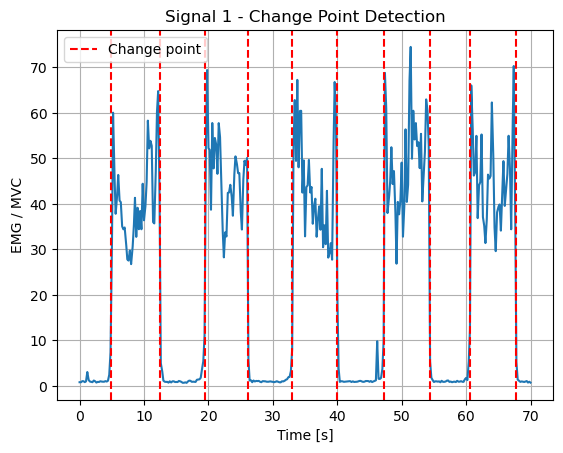

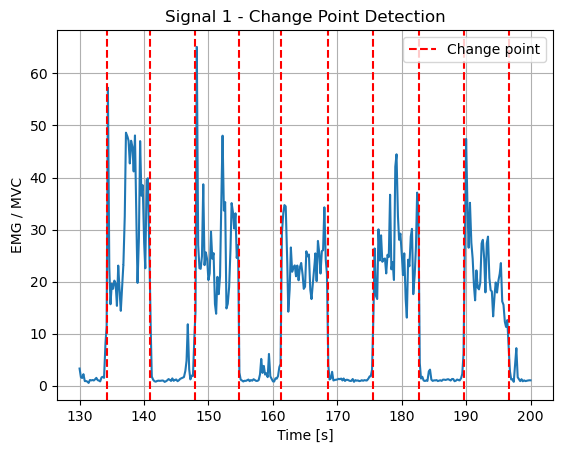

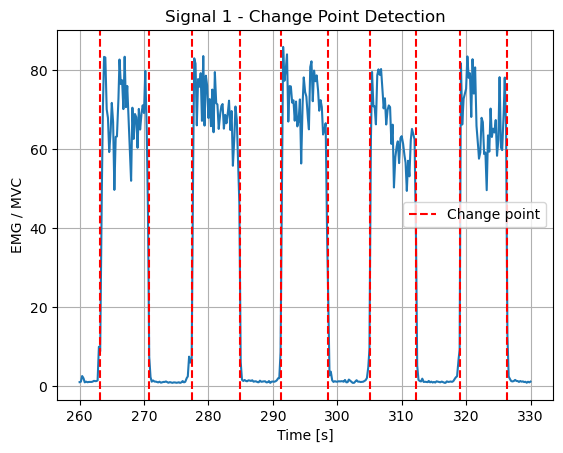

In [16]:
emg_smoo_cut_myo, emg_filt_cut_myo, emg_time_cut_myo, breakpoints_myo = detect_segments_v2(emg_time_myo, muscle_emg_smoothed_myo, 
    muscle_emg_filtered_myo, channel_names, channel_ref, windows_idx_list_myo, intensity_level, n_lifts, fs_list_myo, flag=True)

In [17]:
diff = compute_offset_trigno_myo(emg_time_trigno, emg_time_myo, fs_list_trigno, windows_trigno, intensity_level,
    muscle_emg_smoothed_trigno, muscle_ref, breakpoints_myo, n_lifts)


Offset #1 Trigno - Myo: 2.9884 s


In [18]:
(emg_time_trigno, muscle_emg_smoothed_trigno, 
muscle_emg_filtered_trigno, breakpoints_trigno) = align_and_get_bkps_trigno(emg_time_trigno, emg_time_myo, muscle_emg_smoothed_trigno,
                                                                           muscle_emg_filtered_trigno, breakpoints_myo, muscle_names, diff)

In [19]:
emg_smoo_cut_trigno, emg_filt_cut_trigno, emg_time_cut_trigno, _ = detect_segments_v2(emg_time_trigno, muscle_emg_smoothed_trigno, 
    muscle_emg_filtered_trigno, muscle_names, muscle_ref, windows_idx_list_trigno, intensity_level, n_lifts, fs_list_trigno, flag=False)

In [20]:
emg_norm_cut_myo, max_val_dict_myo = normalize_emg_data(emg_smoo_cut_myo, fs_list_myo, channel_names, time_factor, smooth_threshold_myo)

In [21]:
emg_norm_cut_trigno, max_val_dict_trigno = normalize_emg_data(emg_smoo_cut_trigno, fs_list_trigno, muscle_names, time_factor, smooth_threshold_trigno)

In [22]:
#max_val_dict = max_val_dict_myo | max_val_dict_trigno
#df_max = pd.DataFrame.from_dict(max_val_dict, orient='index', columns=['max_val'])
#df_max.to_csv(full_path_new_mvc)

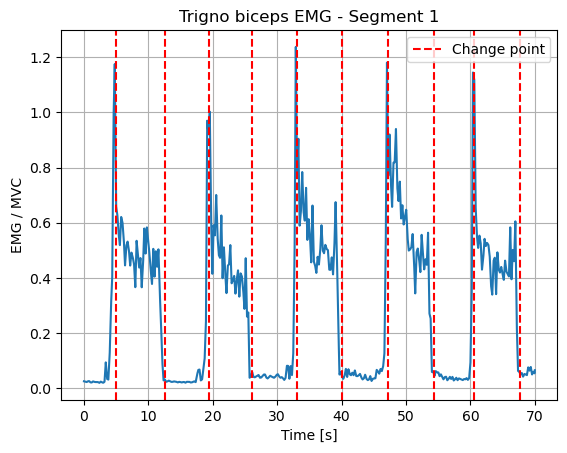

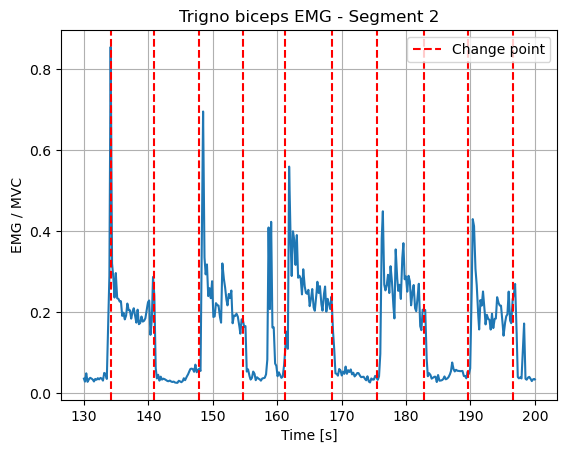

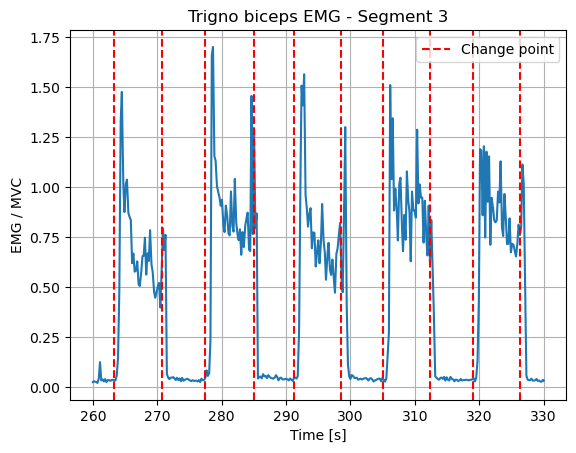

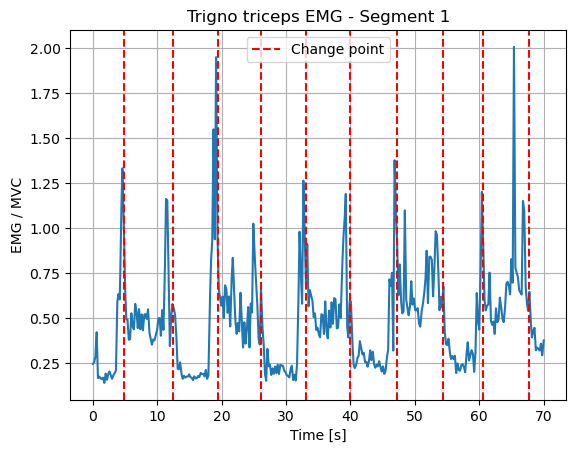

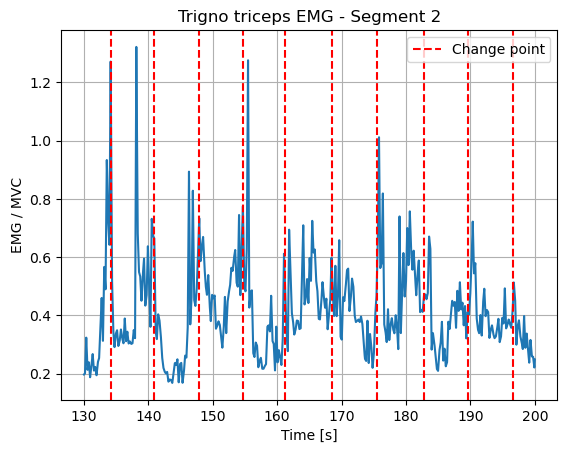

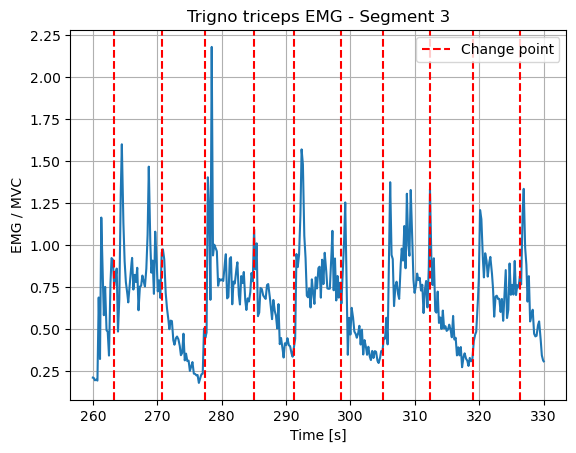

In [23]:
for muscle in muscle_names:
    for i in range(len(emg_time_cut_trigno[muscle])):
        signal = emg_norm_cut_trigno[muscle][i]
        time = emg_time_cut_trigno[muscle][i]
        start_idx = i * n_lifts * 2
        end_idx = start_idx + n_lifts * 2
        breakpoints_sl = breakpoints_trigno[start_idx:end_idx]  
        plot_emg_signal(signal, time, title=f"Trigno {muscle} EMG - Segment {i+1}", xlabel="Time [s]", ylabel="EMG / MVC", breakpoints=breakpoints_sl)

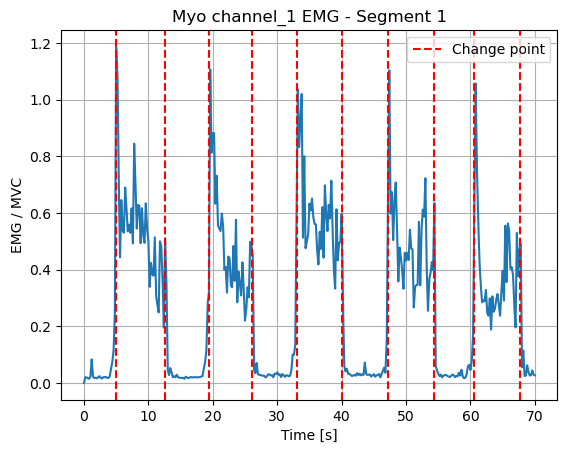

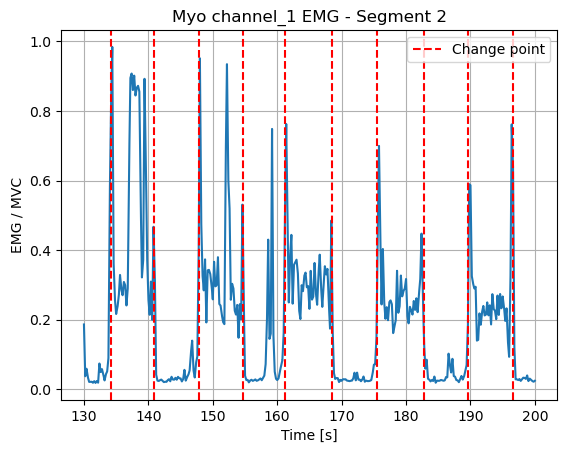

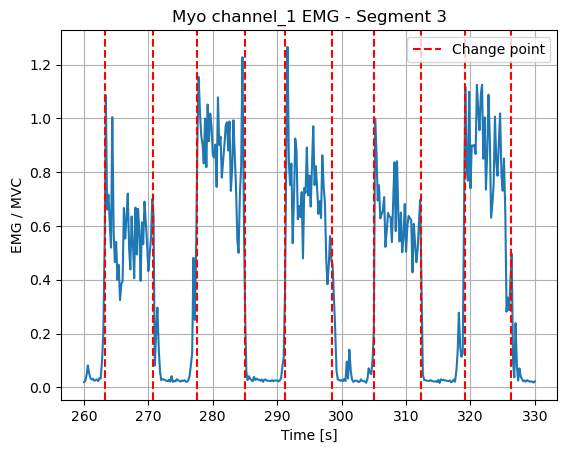

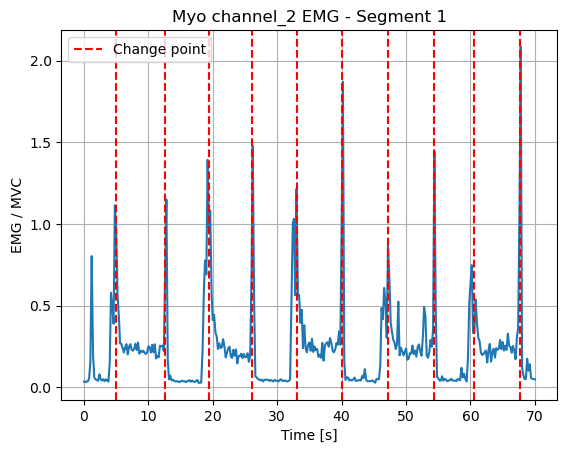

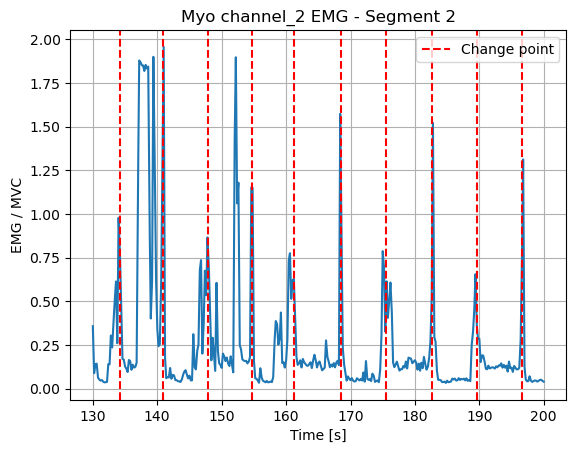

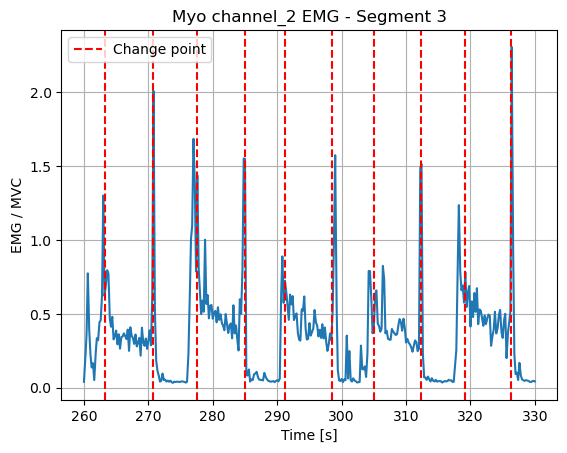

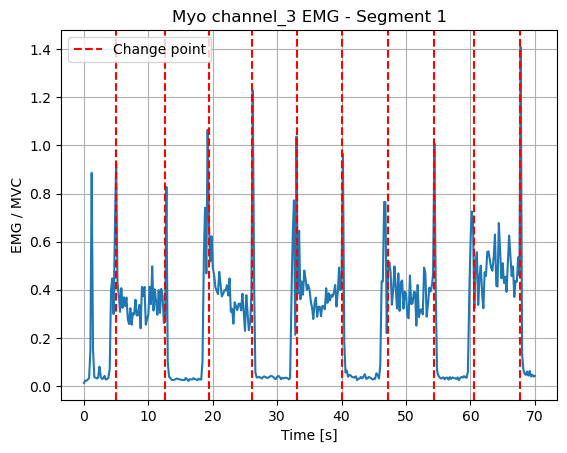

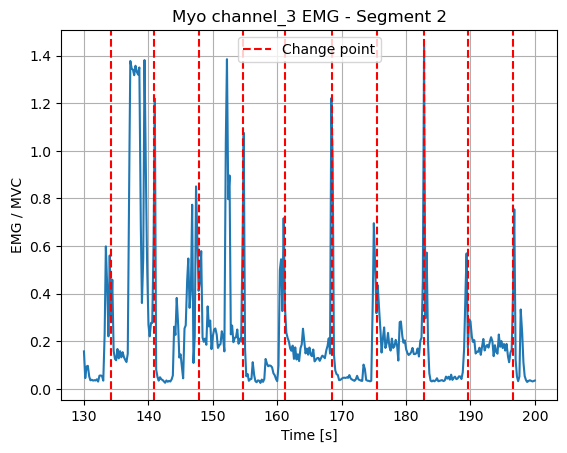

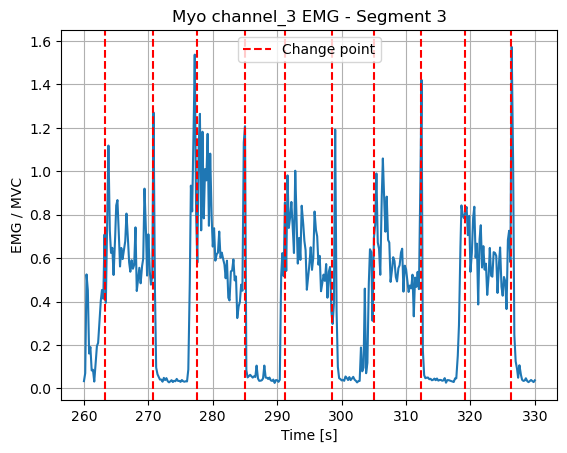

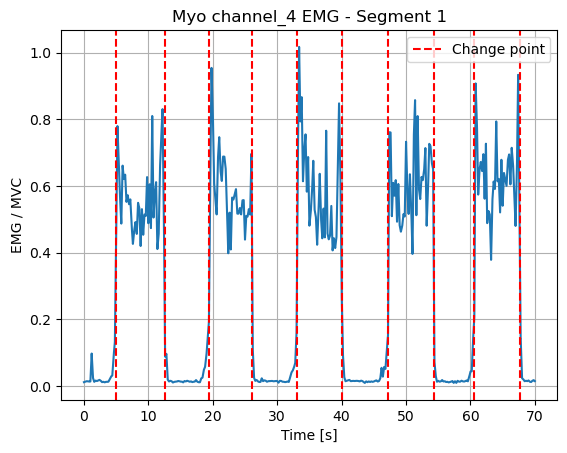

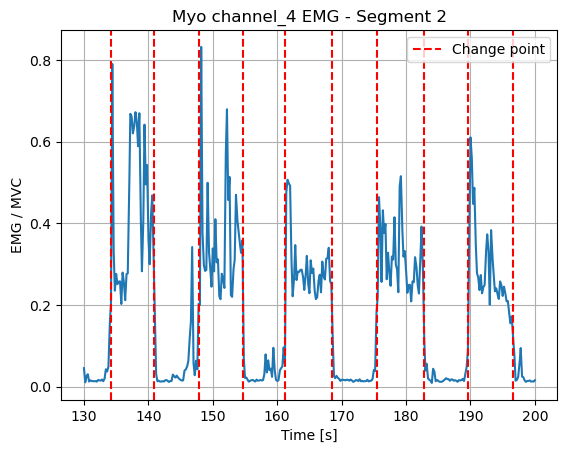

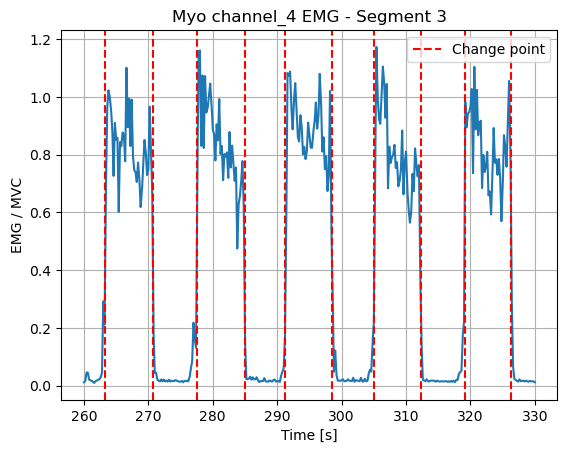

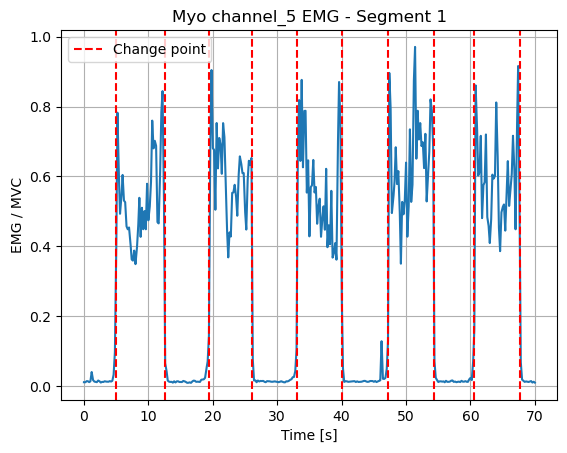

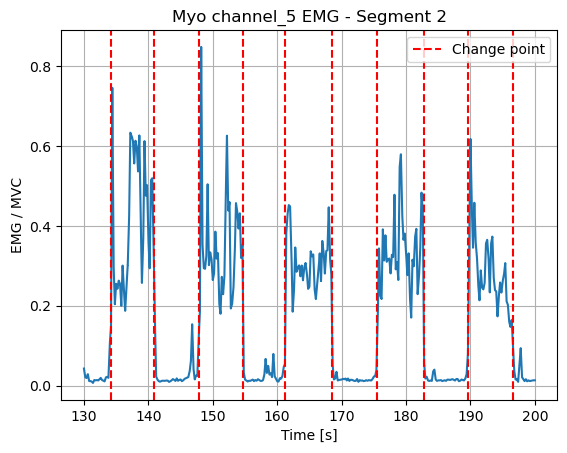

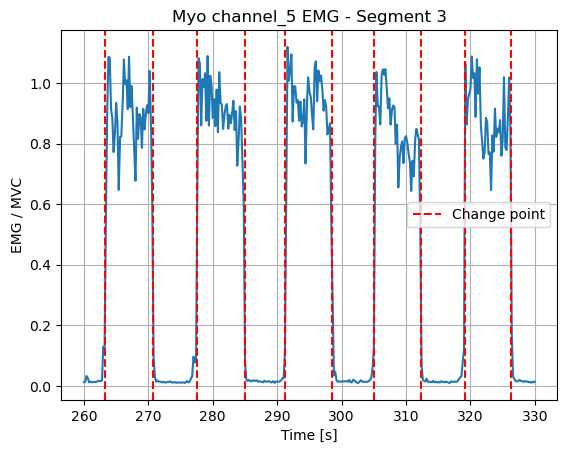

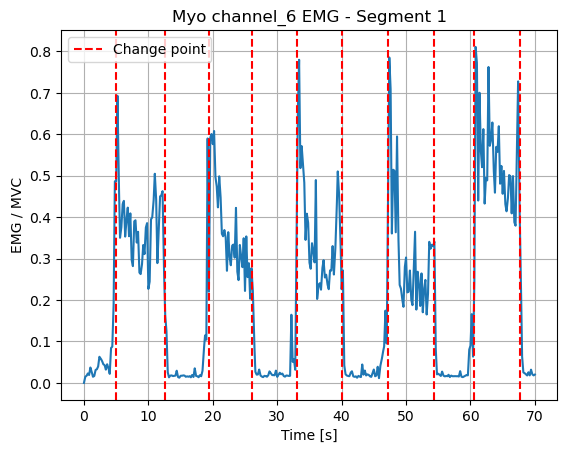

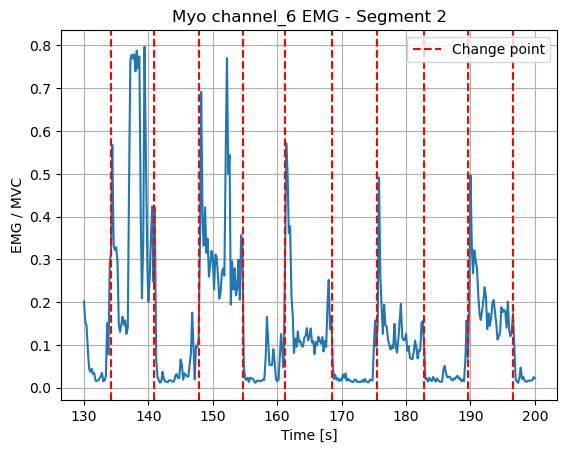

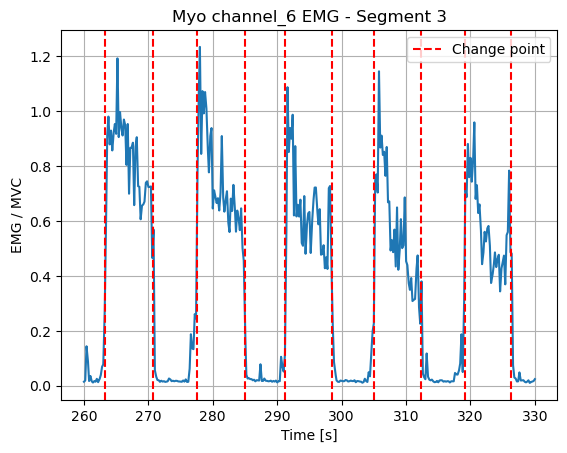

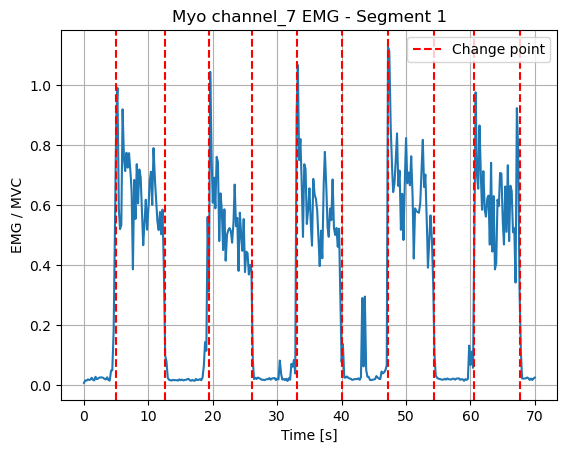

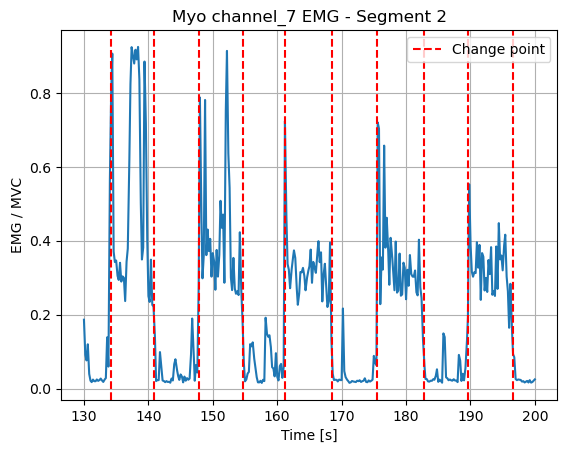

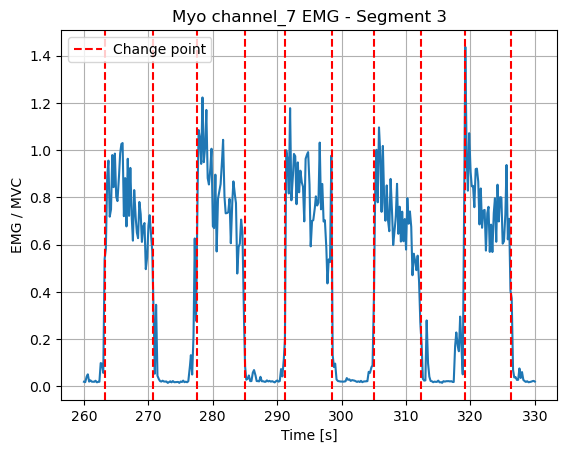

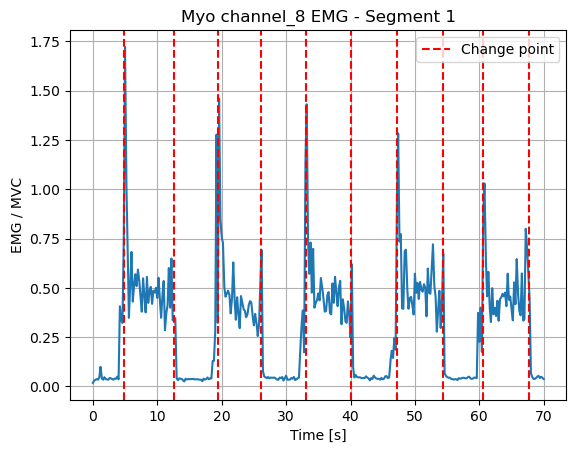

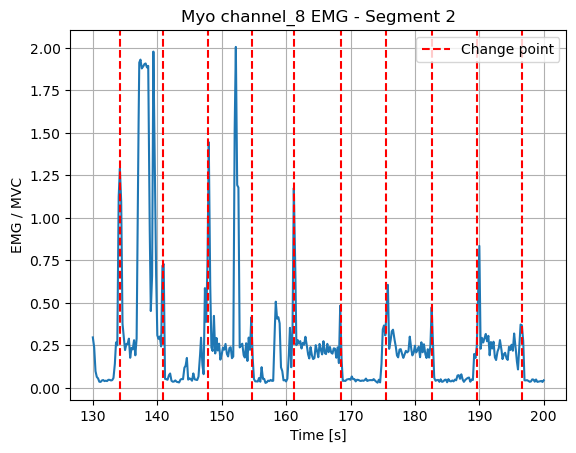

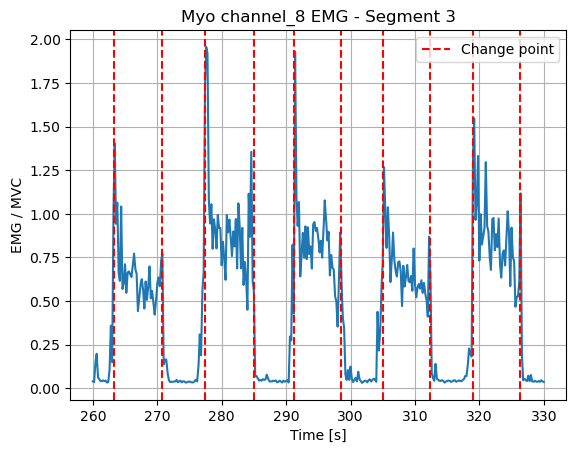

In [24]:
for channel in channel_names:
    for i in range(len(emg_time_cut_myo[channel])):
        signal = emg_norm_cut_myo[channel][i]
        time = emg_time_cut_myo[channel][i]
        breakpoints_sl = breakpoints_myo[i]  
        plot_emg_signal(signal, time, title=f"Myo {channel} EMG - Segment {i+1}", xlabel="Time [s]", ylabel="EMG / MVC", breakpoints=breakpoints_sl)

## Windowing & Feature Extraction

MYO

In [29]:
normalized_win_myo, filtered_win_myo, time_win_myo = extract_emg_windows_v2(emg_norm_cut_myo, emg_filt_cut_myo, emg_time_cut_myo, w_d, ov)

In [30]:
# Features Extraction
time_features_norm_myo = extract_emg_features(normalized_win_myo, features_list_norm)  # Extract time-domain features from normalized EMG windows
time_features_filt_myo = extract_emg_features(filtered_win_myo, features_list_filt)  # Extract time-domain features from filtered EMG windows
freq_features_norm_myo = extract_emg_features(normalized_win_myo, features_list_freq)  # Extract frequency-domain features from normalized EMG windows 

TRIGNO

In [31]:
normalized_win_trigno, filtered_win_trigno, time_win_trigno = extract_emg_windows_v2(emg_norm_cut_trigno, emg_filt_cut_trigno, emg_time_cut_trigno,
                                                                                     w_d, ov)

In [32]:
# Features Extraction
time_features_norm_trigno = extract_emg_features(normalized_win_trigno, features_list_norm)  
time_features_filt_trigno = extract_emg_features(filtered_win_trigno, features_list_filt)  
freq_features_norm_trigno = extract_emg_features(normalized_win_trigno, features_list_freq) 

In [33]:
dfs = combine_multiple_features_lists(time_features_norm_myo, time_features_filt_myo, freq_features_norm_myo, 
                                      time_features_norm_trigno, time_features_filt_trigno, freq_features_norm_trigno) 

## Label Assignment

In [37]:
dfs['label'] = assign_emg_labels_v2(breakpoints_myo, windows_per_segment, fs_list_ext_myo, w_d, ov, intensity_level, n_lifts)

# Features Export

In [38]:
output_path = os.path.join(output_folder, output_filename)  # Create full path for output CSV file
dfs.to_csv(output_path, index=False)  # Save dataframe with features and labels to CSV